# Backpropagation task

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

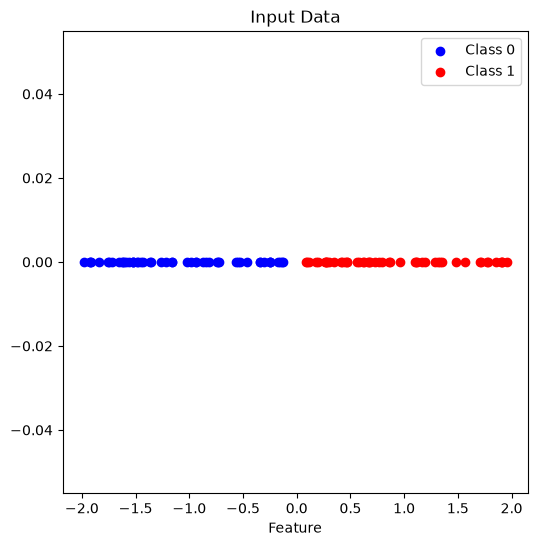

In [2]:
# Generate synthetic data for classification
np.random.seed(0)
X = np.random.uniform(-2, 2, size=(100, 1))  # 100 samples, 1 feature
y = (X >= 0).astype(int)  # Binary classification: 1 if X >= 0, else 0

# Plot the data
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0], np.zeros_like(X[y==0]), color='blue', label='Class 0')
plt.scatter(X[y==1], np.zeros_like(X[y==1]), color='red', label='Class 1')
plt.title('Input Data')
plt.xlabel('Feature')
plt.legend()
plt.show()

First, initialise the parameters. This means determining the following:

**Size of the network**

Hidden layers (or a single hidden layer in this example) can be any size. Layers with more neurons are more powerful, but also more likely to overfit, and take longer to train. The output layer size corresponds to the number of classes.

**Number of iterations**

This parameter determines how many times the network will be updated.

**Learning rate**

Each time we update the weights, we do so by taking a step into the direction that we calculated will improve the accuracy of the network. The size of that step is determined by the learning rate. Taking small steps will slow the process down, but taking steps that are too large can cause results to vary wildly and not reach a stable optimum.

In [3]:
# Activation functions and derivatives

def sigmoid(values):
    """Return sigmoid activation."""
    return 1.0 / (1.0 + np.exp(-values))


def sigmoid_derivative_from_output(activated_values):
    """Return derivative of sigmoid using activated output."""
    return activated_values * (1.0 - activated_values)


def relu(values):
    """Return ReLU activation."""
    return np.maximum(0.0, values)


def relu_derivative(values):
    """Return derivative of ReLU."""
    return (values > 0).astype(float)


def tanh(values):
    """Return tanh activation."""
    return np.tanh(values)


def tanh_derivative_from_output(activated_values):
    """Return derivative of tanh using activated output."""
    return 1.0 - activated_values ** 2


def hidden_activation_forward(values, activation_name):
    """Apply chosen hidden-layer activation."""
    if activation_name == "sigmoid":
        return sigmoid(values)
    if activation_name == "relu":
        return relu(values)
    if activation_name == "tanh":
        return tanh(values)
    raise ValueError("activation_name must be 'sigmoid', 'relu', or 'tanh'.")


def hidden_activation_derivative(values, activated_values, activation_name):
    """Return derivative for chosen hidden-layer activation."""
    if activation_name == "sigmoid":
        return sigmoid_derivative_from_output(activated_values)
    if activation_name == "relu":
        return relu_derivative(values)
    if activation_name == "tanh":
        return tanh_derivative_from_output(activated_values)
    raise ValueError("activation_name must be 'sigmoid', 'relu', or 'tanh'.")


def initialize_parameters(input_size, hidden_size, output_size, seed=0):
    """Initialize random weights and biases."""
    rng = np.random.default_rng(seed)
    params = {
        "W1": rng.normal(0, 0.5, size=(input_size, hidden_size)),
        "b1": np.zeros((1, hidden_size)),
        "W2": rng.normal(0, 0.5, size=(hidden_size, output_size)),
        "b2": np.zeros((1, output_size)),
    }
    return params


# Initialize required parameters
input_size = 1
hidden_size = 4
output_size = 1
num_iter = 5000
learning_rate = 0.1

Next, fill in the code below to train a multi-layer perceptron and see if it correctly classifies the input.

In [4]:
def train_mlp(
    inputs,
    targets,
    input_size,
    hidden_size,
    output_size,
    num_iter,
    learning_rate,
    hidden_activation="sigmoid",
    seed=0,
):
    """Train a one-hidden-layer MLP with backpropagation for binary classification."""
    params = initialize_parameters(input_size, hidden_size, output_size, seed=seed)
    targets = targets.reshape(-1, 1)
    sample_count = inputs.shape[0]
    losses = []

    for iteration in range(num_iter):
        # Forward pass
        z1 = np.dot(inputs, params["W1"]) + params["b1"]
        a1 = hidden_activation_forward(z1, hidden_activation)
        z2 = np.dot(a1, params["W2"]) + params["b2"]
        y_pred = sigmoid(z2)

        # Binary cross-entropy loss
        epsilon = 1e-10
        loss = -np.mean(
            targets * np.log(y_pred + epsilon)
            + (1.0 - targets) * np.log(1.0 - y_pred + epsilon)
        )
        losses.append(loss)

        # Backward pass
        dz2 = y_pred - targets
        dW2 = np.dot(a1.T, dz2) / sample_count
        db2 = np.sum(dz2, axis=0, keepdims=True) / sample_count

        da1 = np.dot(dz2, params["W2"].T)
        dz1 = da1 * hidden_activation_derivative(z1, a1, hidden_activation)
        dW1 = np.dot(inputs.T, dz1) / sample_count
        db1 = np.sum(dz1, axis=0, keepdims=True) / sample_count

        # Gradient descent updates
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1

    return params, np.array(losses)


def predict_mlp(inputs, params, hidden_activation="sigmoid"):
    """Return probabilities and class predictions."""
    z1 = np.dot(inputs, params["W1"]) + params["b1"]
    a1 = hidden_activation_forward(z1, hidden_activation)
    z2 = np.dot(a1, params["W2"]) + params["b2"]
    probabilities = sigmoid(z2)
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions


# Baseline training run for the required 1-4-1 architecture
baseline_params, baseline_losses = train_mlp(
    inputs=X,
    targets=y,
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_iter=num_iter,
    learning_rate=learning_rate,
    hidden_activation="sigmoid",
    seed=0,
)

baseline_probabilities, baseline_predictions = predict_mlp(
    X,
    baseline_params,
    hidden_activation="sigmoid",
)
baseline_accuracy = np.mean(baseline_predictions == y) * 100.0

print(f"Baseline settings: learning_rate={learning_rate}, num_iter={num_iter}, hidden_size={hidden_size}")
print(f"Final baseline loss: {baseline_losses[-1]:.4f}")
print(f"Baseline training accuracy: {baseline_accuracy:.2f}%")

Baseline settings: learning_rate=0.1, num_iter=5000, hidden_size=4
Final baseline loss: 0.0135
Baseline training accuracy: 100.00%


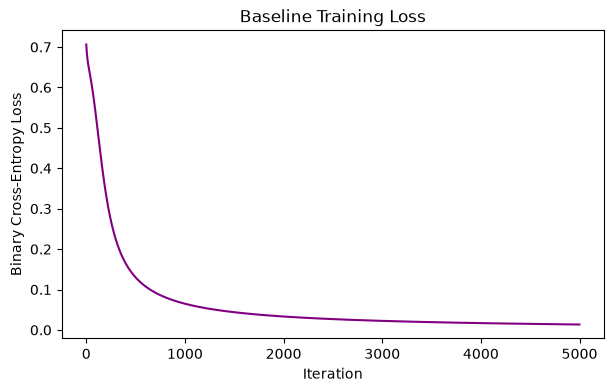

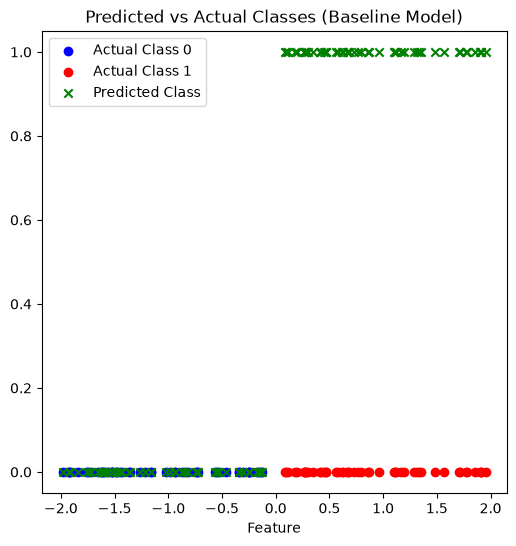

In [5]:
# Plot loss curve
plt.figure(figsize=(7, 4))
plt.plot(baseline_losses, color="purple")
plt.title("Baseline Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

# Plot predicted vs actual classes
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0], np.zeros_like(X[y == 0]), color="blue", label="Actual Class 0")
plt.scatter(X[y == 1], np.zeros_like(X[y == 1]), color="red", label="Actual Class 1")
plt.scatter(X, baseline_predictions, color="green", marker="x", label="Predicted Class")
plt.title("Predicted vs Actual Classes (Baseline Model)")
plt.xlabel("Feature")
plt.legend()
plt.show()

## Experiment Results and Comments

### 1. Learning rate and number of iterations
The table printed in the next cell compares different values. In general, moderate learning rates (such as 0.05 to 0.2) with enough iterations gave stable and accurate results.

### 2. Hidden-layer size
Changing hidden nodes affects model flexibility:
- Fewer nodes can underfit.
- More nodes can fit faster but may be less stable for some settings.

### 3. Activation function change
The hidden-layer activation is changed from sigmoid to alternatives (tanh and ReLU) in the next experiment. This can change convergence speed and final accuracy depending on the learning rate and iteration budget.

In [6]:
# Experiment 1: Learning rate and iterations
learning_rate_options = [0.01, 0.05, 0.1, 0.2]
iteration_options = [1000, 3000, 5000]

print("Learning rate / iteration experiments:")
for lr in learning_rate_options:
    for iterations in iteration_options:
        exp_params, exp_losses = train_mlp(
            inputs=X,
            targets=y,
            input_size=1,
            hidden_size=4,
            output_size=1,
            num_iter=iterations,
            learning_rate=lr,
            hidden_activation="sigmoid",
            seed=0,
        )
        _, exp_predictions = predict_mlp(X, exp_params, hidden_activation="sigmoid")
        exp_accuracy = np.mean(exp_predictions == y) * 100.0
        print(
            f"learning_rate={lr:<4} iterations={iterations:<4} "
            f"loss={exp_losses[-1]:.4f} accuracy={exp_accuracy:6.2f}%"
        )

# Experiment 2: Hidden layer size
hidden_size_options = [2, 4, 8]
print("\nHidden-layer size experiments:")
for current_hidden_size in hidden_size_options:
    exp_params, exp_losses = train_mlp(
        inputs=X,
        targets=y,
        input_size=1,
        hidden_size=current_hidden_size,
        output_size=1,
        num_iter=5000,
        learning_rate=0.1,
        hidden_activation="sigmoid",
        seed=0,
    )
    _, exp_predictions = predict_mlp(X, exp_params, hidden_activation="sigmoid")
    exp_accuracy = np.mean(exp_predictions == y) * 100.0
    print(
        f"hidden_size={current_hidden_size:<2} "
        f"loss={exp_losses[-1]:.4f} accuracy={exp_accuracy:6.2f}%"
    )

# Experiment 3: Change hidden-layer activation function
activation_options = ["sigmoid", "tanh", "relu"]
print("\nHidden activation experiments:")
for activation_name in activation_options:
    exp_params, exp_losses = train_mlp(
        inputs=X,
        targets=y,
        input_size=1,
        hidden_size=4,
        output_size=1,
        num_iter=5000,
        learning_rate=0.1,
        hidden_activation=activation_name,
        seed=0,
    )
    _, exp_predictions = predict_mlp(X, exp_params, hidden_activation=activation_name)
    exp_accuracy = np.mean(exp_predictions == y) * 100.0
    print(
        f"activation={activation_name:<7} "
        f"loss={exp_losses[-1]:.4f} accuracy={exp_accuracy:6.2f}%"
    )

Learning rate / iteration experiments:
learning_rate=0.01 iterations=1000 loss=0.5252 accuracy= 96.00%
learning_rate=0.01 iterations=3000 loss=0.2232 accuracy=100.00%
learning_rate=0.01 iterations=5000 loss=0.1301 accuracy=100.00%
learning_rate=0.05 iterations=1000 loss=0.1302 accuracy=100.00%
learning_rate=0.05 iterations=3000 loss=0.0439 accuracy=100.00%
learning_rate=0.05 iterations=5000 loss=0.0268 accuracy=100.00%
learning_rate=0.1  iterations=1000 loss=0.0650 accuracy=100.00%
learning_rate=0.1  iterations=3000 loss=0.0225 accuracy=100.00%
learning_rate=0.1  iterations=5000 loss=0.0135 accuracy=100.00%
learning_rate=0.2  iterations=1000 loss=0.0333 accuracy=100.00%
learning_rate=0.2  iterations=3000 loss=0.0112 accuracy=100.00%
learning_rate=0.2  iterations=5000 loss=0.0066 accuracy=100.00%

Hidden-layer size experiments:
hidden_size=2  loss=0.0142 accuracy=100.00%
hidden_size=4  loss=0.0135 accuracy=100.00%
hidden_size=8  loss=0.0133 accuracy=100.00%

Hidden activation experiment